# Introduction to Machine Learning

## Definition

**Machine learning** is a branch of artificial intelligence where computers learn patterns from data to make predictions or decisions without being explicitly programmed for every scenario.

In Python, **Scikit-learn** (imported as **sklearn**) is the standard library used to build and apply machine learning models.

---

## Why It Matters

Traditional programming requires writing manual rules for every possible situation. When problems become too complex, writing manual rules becomes nearly impossible.

Machine learning solves this by using algorithms to discover patterns automatically from past data. This approach allows software to scale and adapt to complex, real-world problems like spam detection, image recognition, and recommendation systems.

---

## How It Works

Machine learning generally follows a structured, step-by-step pipeline:

* **Data Collection**: Gathering historical information relevant to the problem.
* **Data Preprocessing**: Cleaning, scaling, and transforming raw data into a numerical format algorithms can read.
* **Model Selection**: Choosing an algorithm suited for the task, such as classification or regression.
* **Training**: Passing historical data to the model so it can learn underlying patterns.
* **Evaluation**: Testing the model on unseen data to measure its predictive accuracy.

---

## Machine Learning Types

Machine learning tasks are primarily divided into three main categories:

| Type | Goal | Example |
| --- | --- | --- |
| **Supervised Learning** | Predict targets using labeled data | Predicting house prices or detecting email spam |
| **Unsupervised Learning** | Discover hidden patterns in unlabeled data | Customer segmentation or grouping similar news articles |
| **Reinforcement Learning** | Learn optimal actions through trial and reward | Training autonomous vehicles or game-playing agents |

---
## ML Workflow

```text
Raw Data  
↓  
Data Cleaning  
↓  
Separate X (features) and y (target)  
↓  
Train-Test Split  
↓  
Fit Scaler on X_train  
↓  
Transform X_train using Scaler  
↓  
Transform X_test using SAME Scaler  
↓  
Apply SMOTE to X_train, y_train ONLY  
↓  
Fit Model on Resampled Training Data  
↓  
Predict X_test  
↓  
Evaluate using `classification_report(y_test, y_pred)`
```

---

## Common Mistakes

* **Overfitting**: Training a model that memorizes the training data perfectly but fails to predict unseen data accurately.
* **Data Leakage**: Accidentally sharing information from the test dataset with the training dataset during preprocessing.
* **Ignoring Data Quality**: Feeding poor or uncleaned data into a model, which leads to unreliable predictions.

---

## Quick Recap

* **Machine learning** enables algorithms to learn patterns directly from data.
* **Scikit-learn** (**sklearn**) is Python's primary library for applying machine learning algorithms.


* **Supervised learning** uses labeled data, while **unsupervised learning** works with unlabeled data.
* The standard workflow involves preprocessing data, training a model, and evaluating its performance.

In [1]:
# Downloading sklearn package
! pip install scikit-learn 

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: C:\Users\Dell\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd

In [3]:
# Reading the csv
data = pd.read_csv("data/heartdisease.csv")

In [4]:
data

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0
4237,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0
4238,1,40,3.0,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0


In [7]:
print(f"Rows: {data.shape[0]}\nColumns: {data.shape[1]}")

Rows: 4240
Columns: 16


In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


In [9]:
data.columns

Index(['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD'],
      dtype='str')

In [10]:
# Checking for nulls and duplicates in dataset
print(data.isna().sum())
print(f"\nTotal Duplicates: {data.duplicated().sum()}")

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

Total Duplicates: 0


In [11]:
# Dropping the nulls
data = data.dropna()

In [12]:
data.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000
mean,0.443685,49.551941,1.980317,0.489065,9.025424,0.030344,0.005741,0.311646,0.027064,236.847731,132.370558,82.917031,25.782802,75.730727,81.852925,0.152269
std,0.496886,8.562029,1.022656,0.499949,11.921590,0.171557,0.075561,0.463229,0.162292,44.097681,22.086866,11.974258,4.065601,11.981525,23.904164,0.359331
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,113.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.080000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.380000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,143.875000,90.000000,28.037500,82.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,600.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


### Feature and Target Columns

**Feature columns** are the input variables used to make predictions. **Target columns** contain the actual outcomes or values the model aims to predict.

Right now for this dataset:  
**Feature Columns**: `'male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose'`

**Target Column**: `'TenYearCHD'`

**NOTE**: `TenYearCHD` stands for `10 year risk of Coronary Heart Disease`


In [13]:
x = data.drop(columns=["TenYearCHD"]) # Feature Columns
y = data["TenYearCHD"] # Target Column

### `train_test_split()` Function

The **`train_test_split()`** function divides a dataset into **training and testing subsets**.

* **Training data:** Used to train the model.
* **Testing data:** Used to evaluate the model on unseen data.

### Return Values

```text
X_train → Feature data used for training
X_test  → Feature data used for testing
y_train → Target values used for training
y_test  → Target values used for testing
```

### Important Parameters

| Parameter      | Purpose                                                                                                          |
| -------------- | ---------------------------------------------------------------------------------------------------------------- |
| `X`            | Feature data to be split                                                                                         |
| `y`            | Target data to be split                                                                                          |
| `test_size`    | Specifies how much data should be used for testing. `0.2` means 20% testing and 80% training.                    |
| `random_state` | Controls the random split. Using the same number produces the same split each time, making results reproducible. |
| `stratify=y`   | Maintains approximately the same proportion of target classes in both training and testing sets.                 |


In [14]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)



**In simple terms:** Split the features and target into training and testing data, use 20% for testing, make the split reproducible, and preserve the target-class proportions.


### Data Scaling with StandardScaler and MinMaxScaler

Data scaling is a preprocessing technique used in machine learning to transform numerical features so they share a comparable scale. It ensures that feature magnitudes do not unfairly influence model performance or optimization algorithms.

---

#### Definition

**Data scaling** alters the range or distribution of numerical values without changing the underlying relationships between data points.

In machine learning, algorithms compute distances, gradients, or weight updates based on feature values. If one feature ranges from 0 to 1 and another ranges from 1,000 to 100,000, the larger feature will disproportionately dominate calculations, even if it is not inherently more important.

---

#### Why It Matters

Many machine learning algorithms perform poorly or converge slowly when features exist on vastly different numerical scales.

Scaling is essential for:

* **Distance-based algorithms**: Models like K-Nearest Neighbors (KNN), Support Vector Machines (SVM), and K-Means clustering rely on Euclidean distance calculations. Unscaled features with large ranges distort distance measurements.
* **Gradient-based algorithms**: Linear regression, logistic regression, and neural networks optimize weights using gradient descent. Feature scaling ensures balanced weight updates and faster convergence.
* **Regularized models**: Ridge and Lasso regression apply penalties based on weight size. Without scaling, larger features face unfair penalization penalties simply due to their unit scale.

Algorithms based on decision trees (such as Random Forests and XGBoost) are scale-invariant and generally do not require feature scaling.

---

#### How They Work

`StandardScaler` and `MinMaxScaler` are two primary scaling techniques provided by machine learning libraries like `scikit-learn`.

##### StandardScaler (Standardization)

`StandardScaler` transforms features by shifting the mean to `0` and scaling the standard deviation to `1` (z-score normalization).

* **Resulting distribution**: Centered at `0` with a standard deviation of `1`.
* **Value bounds**: Unbounded; values can extend beyond `-1` or `1`.
* **Outlier handling**: Retains the relative impact of outliers, though extreme outliers can shrink the variance of normal values.
* **Best used for**: Algorithms that assume normally distributed data or models sensitive to variance, such as linear models, principal component analysis (PCA), and neural networks.

##### MinMaxScaler (Normalization)

`MinMaxScaler` rescales features to a fixed range, typically between `0` and `1`.

* **Resulting distribution**: Bounded strictly within the specified range (usually `0` to `1`).
* **Value bounds**: Fixed lower and upper limits.
* **Outlier handling**: Highly sensitive to outliers. A single extreme outlier compresses the non-outlier data into a tiny interval, reducing feature variance.
* **Best used for**: Algorithms that require bounded inputs, non-gaussian distributions, or bounded features like image processing pixel values (`0` to `255`).

---

#### Comparison

| Feature / Aspect | `StandardScaler` | `MinMaxScaler` |
| --- | --- | --- |
| **Output Range** | Unbounded (centered at `0`) | Fixed range (typically `0` to `1`) |
| **Mean & Variance** | Mean = `0`, Variance = `1` | Varies based on data boundaries |
| **Sensitivity to Outliers** | Moderate | High |
| **Preserves Distribution Shape** | Yes | Yes |
| **Common Use Cases** | Linear models, SVM, PCA, Neural Networks | Distance algorithms without normality assumptions, Image Processing |

---

#### Workflow and Preventing Data Leakage

To prevent **data leakage**, parameters learned during scaling (such as mean, standard deviation, minimum, or maximum) must be calculated using **only the training set**.

The scaling workflow follows a mandatory step-by-step order:

1. **Split the dataset** into training and testing sets before applying any scaling transformations.


2. **Fit the scaler** using `fit()` on the **training set only** to calculate feature parameters (e.g., mean and standard deviation).


3. **Transform the training set** using `transform()` or `fit_transform()`.


4. **Transform the test set** using `transform()` with the scaler fitted on the training set. Never fit the scaler on the test set.



---

#### Common Mistakes

* **Fitting the scaler on the full dataset before splitting**
* This leaks information from the test set into the training set, leading to overly optimistic evaluation metrics.




* **Calling `fit()` or `fit_transform()` on the test dataset**
* Calling `fit()` on test data recalibrates the parameters, causing the training and test sets to be scaled on different scales.




* **Scaling target variables unnecessarily**
* Target variables (`y`) usually do not require scaling unless required by specific loss functions or neural network architectures.


* **Using `MinMaxScaler` with severe outliers**
* Extreme outliers cause `MinMaxScaler` to compress most regular data into a very narrow range, discarding feature variability.



---

#### Quick Recap

* **Data scaling** brings numerical features to a shared scale, ensuring fair feature representation during model training.


* **`StandardScaler`** centers data around a mean of `0` with unit variance; ideal for standard normal distributions and linear models.
* **`MinMaxScaler`** bounds values within a strict range (usually `0` to `1`); ideal for fixed-bound requirements but sensitive to outliers.
* **Always split before scaling** and fit scalers exclusively on the training set to prevent data leakage.

In [17]:
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()
x_train = scalar.fit_transform(x_train)
x_test = scalar.transform(x_test)

#### Why `fit_transform()` for Training and `transform()` for Testing

We use `fit_transform()` on training data because the scaler must **learn its parameters** (mean and standard deviation) and then scale the data.

We use `transform()` on test data to apply the **same learned parameters**, preventing **data leakage** and ensuring the test set remains truly unseen.


### Data Balancing

#### Definition

**Data balancing** is the process of adjusting a dataset so that all target classes have a roughly equal number of observations. It addresses class imbalance, where one class significantly outnumbers another in a machine learning dataset.

---

#### How It Works

Data balancing works by altering the class distribution of a training set before feeding it into a model. The primary strategies include:

* **Random Oversampling:** Duplicate existing examples from the minority class to increase its representation.


* **Synthetic Oversampling (e.g., SMOTE):** Generate synthetic, mathematically plausible examples for the minority class rather than simple copies.


* **Undersampling:** Randomly remove examples from the majority class to equal the size of the minority class.


* **Class Weight Adjustment:** Modify the model's loss function to impose a higher penalty for misclassifying minority class instances.

<Axes: title={'center': 'Count of Patients with TenYearCHD'}, xlabel='TenYearCHD'>

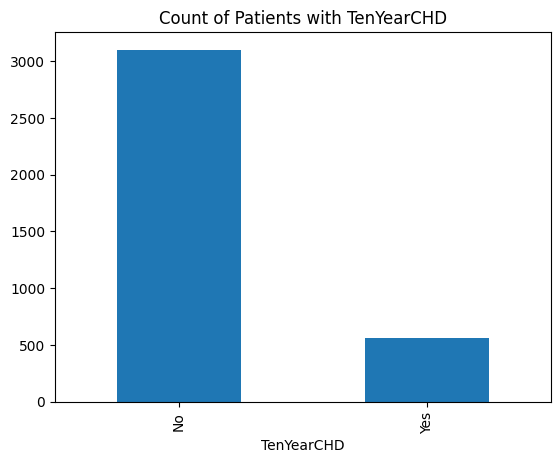

In [18]:
# Right now, our data is highly imbalanced
data["TenYearCHD"].replace({0:"No", 1:"Yes"}).value_counts().plot(kind="bar", title="Count of Patients with TenYearCHD")

In [19]:
# Installing pip version which is compatible with imblearn
! pip install scikit-learn==1.3.2 imbalanced-learn==0.11.0

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: C:\Users\Dell\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [20]:
# Oversampling the class with less labels using SMOTE technique
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
x_train, y_train = smote.fit_resample(x_train, y_train)
y_train.value_counts()

TenYearCHD
0    2480
1    2480
Name: count, dtype: int64

<Axes: title={'center': 'Count of Patients with TenYearCHD'}, xlabel='TenYearCHD'>

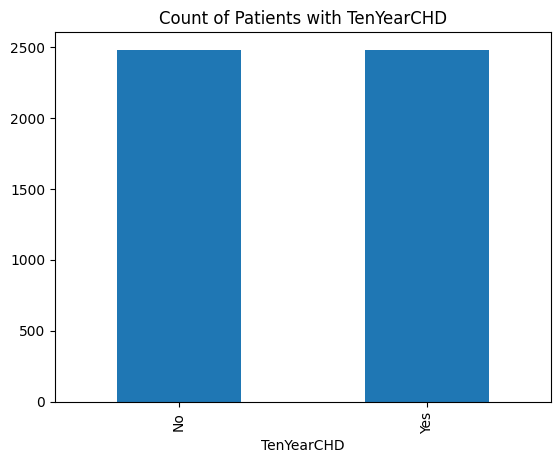

In [21]:
# Now our data looks balanced
y_train.replace({0:"No", 1:"Yes"}).value_counts().plot(kind="bar", title="Count of Patients with TenYearCHD")

## Supervised Learning Algorithms

Supervised learning algorithms build models using labeled datasets. They learn mapping functions from input features to predict correct target outputs.

The two main types of supervised learning are **classification** (predicting discrete labels) and **regression** (predicting continuous numeric values).

---

### Decision Tree Classifier 


#### Definition

A **Decision Tree Classifier** is a supervised learning algorithm that splits data into smaller subsets based on feature values. It structures decisions like a tree of visual choices.

#### Why It Matters

It handles both continuous and categorical data without complex data preparation. Decision trees are highly interpretable because they mimic human decision-making.

#### How It Works

1. Starts at the **root node** representing the full dataset.


2. Evaluates features using split criteria like **Gini Impurity** or **Entropy**.


3. Splits data into **internal nodes** based on optimal feature thresholds.


4. Reaches **leaf nodes**, which represent the final class predictions.



#### Visual Representation

```
       [ Income > $50k? ]
          /          \
        Yes           No
        /              \
  [ Credit > 700? ]   (Reject)
     /        \
   Yes         No
   /            \
(Approve)    (Reject)

```

#### Common Mistakes

* **Overfitting**: Creating trees that are too deep and memorize noisy training data.



#### Quick Recap

* Works by splitting data based on decision rules.


* Structures choices into root, internal, and leaf nodes.


* Easy to visualize and interpret.


* Sensitive to overfitting if tree depth is unconstrained.



---

### Random Forest Classifier 



#### Definition

A **Random Forest Classifier** is an ensemble algorithm that combines multiple decision trees to produce a single, stronger prediction.

#### Why It Matters

Individual decision trees often overfit. Combining predictions from dozens or hundreds of randomized trees dramatically reduces variance and improves accuracy.

#### How It Works

1. Creates multiple subset samples from the original dataset using **bootstrapping** (sampling with replacement).


2. Trains an independent decision tree on each sample using random feature selection.


3. Collects predictions from every individual tree.


4. Applies **majority voting** across all tree outputs to choose the final class.



#### Visual Representation

```
                  [ Input Data ]
                 /      |       \
           [ Tree 1 ] [ Tree 2 ] [ Tree 3 ]
              |          |          |
           (Class A)  (Class B)  (Class A)
                 \      |       /
                 [ Majority Vote ]
                         |
                    (Class A)

```

#### Common Mistakes

* Expecting clear interpretability like a single decision tree.



#### Quick Recap

* Ensemble method combining multiple decision trees.


* Uses bootstrapping and random feature subsets.


* Reduces overfitting compared to single trees.


* Determines final output via majority vote.



---

### Logistic Regression 



#### Definition

**Logistic Regression** is a classification algorithm used to estimate the probability that an instance belongs to a specific binary class.

#### Why It Matters

Despite its name, it is a classification model, not a regression model. It serves as a simple, fast baseline for binary classification problems.

#### How It Works

1. Computes a linear combination of input features and weights.


2. Passes the result through a **Sigmoid activation function**.


3. Maps raw values into a probability value strictly between `0` and `1`.


4. Applies a decision threshold (typically `0.5`) to classify inputs.



#### Visual Representation

```
  Probability (S-Curve)
  1.0 |           ______/
      |          /
  0.5 |........./.......... Threshold
      |        /
  0.0 |_______/__________
             Linear Input (z)

```

#### Common Mistakes

* Assuming Logistic Regression output is useful for non-linear decision boundaries without feature engineering.



#### Quick Recap

* Used primarily for binary classification tasks.


* Uses the Sigmoid function to output probabilities between `0` and `1`.


* Classifies outputs using a decision threshold.


* Works best when classes are linearly separable.



---

### Support Vector Machine (SVM) 



#### Definition

A **Support Vector Machine (SVM)** is a classification algorithm that finds the optimal boundary line or hyperplane to separate different classes.

#### Why It Matters

SVM works exceptionally well on high-dimensional datasets and clearly separated classes.

#### How It Works

1. Identifies **support vectors**, which are the data points closest to the boundary.


2. Calculates the distance between support vectors and the boundary line.


3. Maximizes this distance to create the widest possible **margin**.


4. Uses **kernel tricks** to transform non-linear data into higher dimensions for linear separation.



#### Visual Representation

```
  Class A    |  Margin  |    Class B
    o        |    :     |       x
      o      |    :     |     x   x
        (o) <|....:....|> (x)  <-- Support Vectors
             | Hyperplane |

```

#### Common Mistakes

* Using SVM on large datasets without scaling, as training time scales poorly with dataset size.



#### Quick Recap

* Finds a decision boundary (hyperplane) that maximizes class margins.


* Relies on border points called support vectors.


* Uses kernels to separate non-linear data.


* Performs best on small-to-medium high-dimensional datasets.



---

### K-Nearest Neighbors Classifier (KNN) 



#### Definition

**K-Nearest Neighbors (KNN)** is a non-parametric classification algorithm that predicts an unlabeled point's class based on the majority class of its nearest neighbors.

#### Why It Matters

KNN is an instance-based algorithm that requires no training phase, making it simple to implement.

#### How It Works

1. Selects the number of neighbors, represented by the parameter `k`.


2. Measures distance (e.g., **Euclidean distance**) between target point and all dataset points.


3. Identifies the `k` closest data points.


4. Assigns the majority class among those `k` neighbors to the target point.



#### Visual Representation

```
     Class A   (o)     
            (o)   ?  <-- New Point
               (x)    
            Class B  (x)
      
    If k = 3: 2 Class A vs 1 Class B ---> Predicts Class A

```

#### Common Mistakes

* Choosing an even number for `k`, which can cause tied majority votes.



#### Quick Recap

* Classifies points based on proximity to stored data instances.


* Uses distance metrics like Euclidean distance.


* Does not require an explicit training step.


* Sensitive to unscaled features and noisy data.

In [22]:
# Importing our models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [23]:
dtc_model = DecisionTreeClassifier(class_weight="balanced") # treat both classes equally
rfc_model = RandomForestClassifier(class_weight="balanced")
knc_model = KNeighborsClassifier(n_neighbors=5) # check for 5 nearest neighbors (data points) for label prediction
lr_model = LogisticRegression()
svc_model = SVC(
    kernel='rbf',   # Shape/type of decision boundary (curved)
    C=1.0,          # How strongly mistakes are penalized (medium)
    gamma='scale'   # How far each point's influence reaches (chosen by itself based on data's variance and distribution)
)

# Training our models on the training dataset
dtc_model.fit(x_train, y_train)
rfc_model.fit(x_train, y_train)
knc_model.fit(x_train, y_train)
lr_model.fit(x_train, y_train)
svc_model.fit(x_train, y_train)

SVC()

In [24]:
# Now making our models predict the target column of testing dataset
p_dtc = dtc_model.predict(x_test)
p_rfc = rfc_model.predict(x_test)
p_knc = knc_model.predict(x_test)
p_lr = lr_model.predict(x_test)
p_svc = svc_model.predict(x_test)

In [25]:
# Now evaluating our models accuracy using accuracy_score(), classification_report()
from sklearn.metrics import accuracy_score, classification_report

print(f"Accuracy Score of Decision Tree: {accuracy_score(y_test, p_dtc)}")
print(f"Accuracy Score of Random Forest: {accuracy_score(y_test, p_rfc)}")
print(f"Accuracy Score of K Nearest Neighbors: {accuracy_score(y_test, p_knc)}")
print(f"Accuracy Score of Logistic Regressor: {accuracy_score(y_test, p_lr)}")
print(f"Accuracy Score of SVM: {accuracy_score(y_test, p_svc)}")

Accuracy Score of Decision Tree: 0.75
Accuracy Score of Random Forest: 0.8073770491803278
Accuracy Score of K Nearest Neighbors: 0.6612021857923497
Accuracy Score of Logistic Regressor: 0.6734972677595629
Accuracy Score of SVM: 0.7008196721311475


In [26]:
print(f"Classification Report of Decision Tree:\n{classification_report(y_test, p_dtc)}")

Classification Report of Decision Tree:
              precision    recall  f1-score   support

           0       0.87      0.82      0.85       621
           1       0.25      0.33      0.29       111

    accuracy                           0.75       732
   macro avg       0.56      0.58      0.57       732
weighted avg       0.78      0.75      0.76       732



In [27]:
print(f"Classification Report of Random Forest:\n{classification_report(y_test, p_rfc)}")

Classification Report of Random Forest:
              precision    recall  f1-score   support

           0       0.87      0.91      0.89       621
           1       0.32      0.24      0.28       111

    accuracy                           0.81       732
   macro avg       0.60      0.58      0.58       732
weighted avg       0.79      0.81      0.80       732



In [28]:
print(f"Classification Report of K Neighbors:\n{classification_report(y_test, p_knc)}")

Classification Report of K Neighbors:
              precision    recall  f1-score   support

           0       0.88      0.70      0.78       621
           1       0.21      0.46      0.29       111

    accuracy                           0.66       732
   macro avg       0.55      0.58      0.53       732
weighted avg       0.78      0.66      0.70       732



In [29]:
print(f"Classification Report of Logistic Regressor:\n{classification_report(y_test, p_lr)}")

Classification Report of Logistic Regressor:
              precision    recall  f1-score   support

           0       0.92      0.68      0.78       621
           1       0.27      0.66      0.38       111

    accuracy                           0.67       732
   macro avg       0.59      0.67      0.58       732
weighted avg       0.82      0.67      0.72       732



In [30]:
print(f"Classification Report of SVM:\n{classification_report(y_test, p_svc)}")

Classification Report of SVM:
              precision    recall  f1-score   support

           0       0.89      0.73      0.81       621
           1       0.26      0.51      0.34       111

    accuracy                           0.70       732
   macro avg       0.58      0.62      0.57       732
weighted avg       0.80      0.70      0.74       732



In [31]:
print("End of Day 1")

End of Day 1
